# Finance — Credit-Card Fraud: EDA & Preprocessing

Binary classification on a severely imbalanced dataset (fraud ≈ 0.17%). Follows the
same lifecycle as the healthcare notebook: **peek → validate → nulls → visualize →
feature-engineer → split-first → fit transforms on train only**. Scope: ends at the
80/10/10 split (no modeling).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style='whitegrid')
PAL = ['#2a78d6', '#e34948', '#1baf7a', '#eda100']   # validated, CVD-safe (genuine, fraud, ...)
DATA_PATH = '../../data/finance-credit-card-fraud/creditcard.csv'
RANDOM_STATE, TARGET = 42, 'Class'

## 1. Peek: sample 200 rows, then a different 20 rows

In [2]:
df_full = pd.read_csv(DATA_PATH)
print('shape:', df_full.shape)
sample200 = df_full.sample(200, random_state=1)
sample200.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
169876,119907.0,-0.611712,-0.769705,-0.149759,-0.224877,2.028577,-2.019887,0.292491,-0.523020,0.358468,...,-0.075208,0.045536,0.380739,0.023440,-2.220686,-0.201146,0.066501,0.221180,1.79,0
127467,78340.0,-0.814682,1.319219,1.329415,0.027273,-0.284871,-0.653985,0.321552,0.435975,-0.704298,...,-0.128619,-0.368565,0.090660,0.401147,-0.261034,0.080621,0.162427,0.059456,1.98,0
137900,82382.0,-0.318193,1.118618,0.969864,-0.127052,0.569563,-0.532484,0.706252,-0.064966,-0.463271,...,-0.305402,-0.774704,-0.123884,-0.495687,-0.018148,0.121679,0.249050,0.092516,0.89,0
21513,31717.0,-1.328271,1.018378,1.775426,-1.574193,-0.117696,-0.457733,0.681867,-0.031641,0.383872,...,-0.220815,-0.419013,-0.239197,0.009967,0.232829,0.814177,0.098797,-0.004273,15.98,0
134700,80923.0,1.276712,0.617120,-0.578014,0.879173,0.061706,-1.472002,0.373692,-0.287204,-0.084482,...,-0.160161,-0.430404,-0.076738,0.258708,0.552170,0.370701,-0.034255,0.041709,0.76,0


In [3]:
sample200.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,200.0,91976.320000,47492.722268,153.000000,52417.250000,79784.500000,138049.750000,171042.000000
V1,200.0,-0.303167,2.763861,-26.389030,-1.189319,-0.140859,1.353494,2.359425
V2,200.0,-0.162230,2.312236,-17.755687,-0.780395,-0.061188,0.911496,7.068868
V3,200.0,-0.046006,1.681045,-10.278766,-0.865194,0.135375,1.072700,2.652317
V4,200.0,0.111857,1.431111,-4.067605,-0.725253,0.016347,0.772443,10.413010
V5,200.0,-0.137194,1.383592,-9.446086,-0.679278,-0.097098,0.524874,4.794048
V6,200.0,-0.040637,1.204864,-4.089040,-0.777420,-0.212763,0.402074,6.220135
V7,200.0,0.047554,1.179288,-4.883396,-0.476439,0.036795,0.554677,7.705953
V8,200.0,0.004904,0.996782,-7.048197,-0.172882,0.070841,0.283294,4.228662
V9,200.0,0.154784,1.133645,-2.530507,-0.492294,0.076050,0.685148,5.501918


### A different 20 rows

In [4]:
sample20 = df_full.sample(20, random_state=99)
sample20[['Time', 'Amount', 'Class']]   # V1..V28 hidden for readability

,Time,Amount,Class
252556,155864.0,210.45,0
37912,39166.0,9.50,0
241557,151076.0,2.99,0
268242,163125.0,288.90,0
170271,120102.0,12.31,0
156668,108636.0,11.27,0
245815,152922.0,1.00,0
151326,95395.0,135.00,0
74133,55440.0,463.80,0
99541,67166.0,79.99,0


**Observations from the peeks**
- 31 columns, **all numeric** (float/int) — no strings, no obvious categoricals.
- `V1`–`V28` are **PCA-anonymized** components (mean ≈ 0) — individually uninterpretable; we keep them as-is.
- `Time` = seconds since first transaction (spans ~48 h); `Amount` is right-skewed.
- Target `Class`: 0 = genuine, 1 = fraud — extremely rare in any small sample.
- ⚠️ **No categorical column exists in the raw data.** One-hot encoding has nothing to act on
  until we engineer a categorical feature (done in §5).

## 2. Data validation & fixes

In [5]:
print('dtypes:', df_full.dtypes.value_counts().to_dict())
print('duplicate rows:', df_full.duplicated().sum())
print('Class values:', sorted(df_full[TARGET].unique()), '| fraud rate: %.4f%%' % (100*df_full[TARGET].mean()))
print('Amount < 0:', int((df_full.Amount < 0).sum()), '| Time < 0:', int((df_full.Time < 0).sum()))
print('Amount == 0:', int((df_full.Amount == 0).sum()))
print('dupes by class:', df_full[df_full.duplicated()][TARGET].value_counts().to_dict())

dtypes: {dtype('float64'): 30, dtype('int64'): 1}


duplicate rows: 1081
Class values: [np.int64(0), np.int64(1)] | fraud rate: 0.1727%
Amount < 0: 0 | Time < 0: 0
Amount == 0: 1825


dupes by class: {0: 1062, 1: 19}


**Validation issues found**
- **1081 exact duplicate rows** (1062 genuine + 19 fraud) → drop; identical rows are re-submissions / logging artifacts and would leak between splits.
- No negative `Amount`/`Time`; 1825 zero-amount rows are plausible \$0 authorizations → **keep + flag** (§5), don't delete.
- Target is clean binary {0,1}.

In [6]:
df = df_full.drop_duplicates().reset_index(drop=True)
print('after dedup:', df.shape, '| fraud:', int(df[TARGET].sum()),
      '| fraud rate: %.4f%%' % (100*df[TARGET].mean()))

after dedup: (283726, 31) | fraud: 473 | fraud rate: 0.1667%


## 3. Missing values

In [7]:
miss = df.isna().sum()
print('total missing cells:', int(miss.sum()))

total missing cells: 0


No missing values anywhere — no imputation needed.

## 4. Visualization & pattern finding

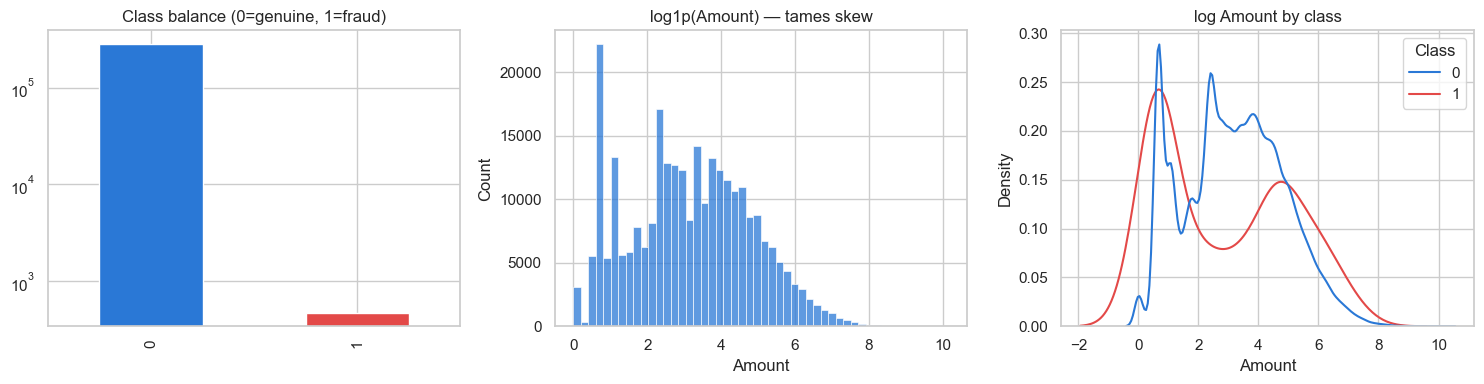

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df[TARGET].value_counts().plot.bar(ax=ax[0], color=PAL[:2])
ax[0].set_title('Class balance (0=genuine, 1=fraud)'); ax[0].set_yscale('log'); ax[0].set_xlabel('')
sns.histplot(np.log1p(df.Amount), bins=50, ax=ax[1], color=PAL[0]); ax[1].set_title('log1p(Amount) — tames skew')
sns.kdeplot(data=df, x=np.log1p(df.Amount), hue=TARGET, common_norm=False, ax=ax[2], palette=PAL[:2])
ax[2].set_title('log Amount by class')
plt.tight_layout(); plt.show()

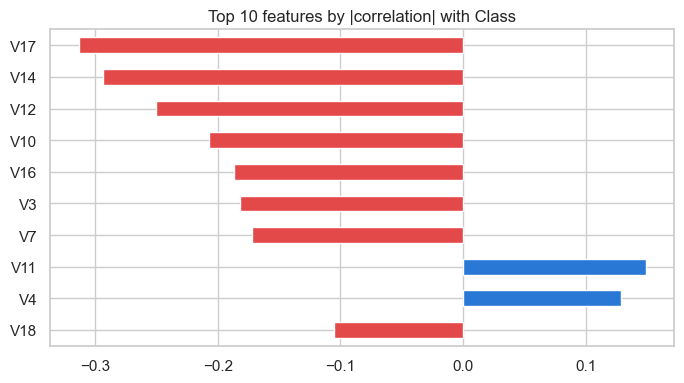

V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182
V7    -0.172
V11    0.149
V4     0.129
V18   -0.105
Name: Class, dtype: float64

In [9]:
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
top = corr.head(10)
plt.figure(figsize=(7, 4))
top.iloc[::-1].plot.barh(color=[PAL[1] if v < 0 else PAL[0] for v in top.iloc[::-1]])
plt.title('Top 10 features by |correlation| with Class'); plt.tight_layout(); plt.show()
top.round(3)

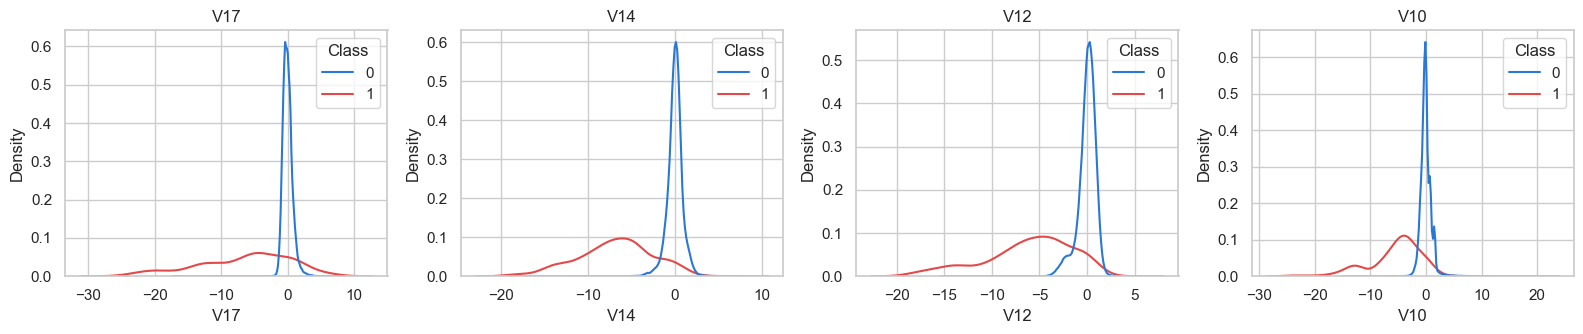

In [10]:
feats = corr.head(4).index.tolist()
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for a, c in zip(ax, feats):
    sns.kdeplot(data=df, x=c, hue=TARGET, common_norm=False, ax=a, palette=PAL[:2]); a.set_title(c)
plt.tight_layout(); plt.show()

**Patterns found**
- **Severe imbalance** (~0.17% fraud) — accuracy is meaningless; evaluate later with PR-AUC / recall.
- Fraud transactions are **smaller** on average (median ≈ \$9 vs \$22) — see the log-Amount KDE.
- A handful of PCA components separate the classes strongly: **V17, V14, V12, V10** (largest |corr|,
  all negative) — their fraud/genuine KDEs are clearly shifted. These will carry most of the signal.
- `Time` alone barely correlates with fraud → raw timestamp is weak; we derive **hour-of-day** instead.

## 5. Feature engineering
Leakage-safe: every feature is a deterministic row-wise function of existing columns (no aggregates).

In [11]:
def add_features(d):
    d = d.copy()
    d['hour']        = (d['Time'] // 3600 % 24).astype(int)   # cyclical time-of-day proxy
    d['log_amount']  = np.log1p(d['Amount'])                   # tame right skew
    d['amount_zero'] = (d['Amount'] == 0).astype(int)          # \$0 authorization flag
    d['amount_bin']  = pd.cut(d['Amount'], bins=[-.01, 1, 10, 50, 200, 1e9],
                              labels=['<1', '1-10', '10-50', '50-200', '200+'])  # <- categorical for OHE
    return d

df = add_features(df)
print('new cols:', ['hour', 'log_amount', 'amount_zero', 'amount_bin'])
df[['Amount', 'log_amount', 'amount_zero', 'amount_bin', 'hour']].head()

new cols: ['hour', 'log_amount', 'amount_zero', 'amount_bin']


,Amount,log_amount,amount_zero,amount_bin,hour
0,149.62,5.014760,0,50-200,0
1,2.69,1.305626,0,1-10,0
2,378.66,5.939276,0,200+,0
3,123.50,4.824306,0,50-200,0
4,69.99,4.262539,0,50-200,0


In [12]:
# does the engineered categorical carry signal?
(df.groupby('amount_bin')[TARGET].mean() * 100).round(3).rename('fraud %')

amount_bin
<1        0.564
1-10      0.096
10-50     0.061
50-200    0.151
200+      0.285
Name: fraud %, dtype: float64

Engineered `hour`, `log_amount`, an `amount_zero` flag, and a categorical `amount_bin`.
The `amount_bin` fraud-rate table above confirms fraud concentrates in the low-amount buckets —
and it gives one-hot encoding a real categorical to work on (the raw data had none).

## 6. Split first (80/10/10, stratified), then fit transforms on train only

In [13]:
feature_cols = [c for c in df.columns if c != TARGET]
X, y = df[feature_cols], df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=.50, stratify=y_tmp, random_state=RANDOM_STATE)

print('sizes  train/val/test:', len(X_train), len(X_val), len(X_test))
print('fraud%%  train/val/test: %.3f %.3f %.3f' % (100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()))

sizes  train/val/test: 226980 28373 28373
fraud%  train/val/test: 0.167 0.169 0.166


## 7. Transformations + scaling (numeric) + one-hot (categorical)
Fit on **train only**. Drop raw `Amount` (kept `log_amount`); one-hot `amount_bin`; pass the binary flag through unchanged.

In [14]:
num_cols  = [c for c in feature_cols if c not in ('amount_bin', 'amount_zero', 'Amount')]
cat_cols  = ['amount_bin']
pass_cols = ['amount_zero']

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('bin', 'passthrough', pass_cols),
])
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)
X_test_t  = pre.transform(X_test)
feat_names = pre.get_feature_names_out()
print('transformed shapes:', X_train_t.shape, X_val_t.shape, X_test_t.shape, '| n_features:', len(feat_names))

transformed shapes: (226980, 37) (28373, 37) (28373, 37) | n_features: 37


In [15]:
print('Any NaN? train/val/test:', np.isnan(X_train_t).any(), np.isnan(X_val_t).any(), np.isnan(X_test_t).any())
pd.DataFrame(X_train_t, columns=feat_names).describe().T.loc[
    ['num__log_amount', 'num__V17', 'num__hour', 'cat__amount_bin_<1', 'bin__amount_zero']].round(3)

Any NaN? train/val/test: False False False


,count,mean,std,min,25%,50%,75%,max
num__log_amount,226980.0,-0.000,1.000,-1.906,-0.758,-0.010,0.731,4.063
num__V17,226980.0,0.000,1.000,-29.844,-0.573,-0.077,0.471,10.976
num__hour,226980.0,-0.000,1.000,-2.411,-0.696,0.162,0.848,1.535
cat__amount_bin_<1,226980.0,0.106,0.308,0.000,0.000,0.000,0.000,1.000
bin__amount_zero,226980.0,0.006,0.079,0.000,0.000,0.000,0.000,1.000


## 8. Summary
- Dropped 1081 duplicate rows; **zero missing values**; kept \$0 authorizations as a flagged signal.
- Confirmed extreme class imbalance (~0.17%) and that **V17/V14/V12/V10** + low amount are the strongest fraud signals.
- Engineered `hour`, `log_amount`, `amount_zero`, `amount_bin`; standardized all numerics + one-hot encoded the binned amount, **fit on train only** (leakage-safe).
- Output: `X_{train,val,test}_t` (80/10/10, stratified) with matching `y_*`, ready for modeling.
- **Next (modeling, out of scope here):** handle imbalance with class weights / SMOTE **inside the training fold only**, and evaluate with PR-AUC & recall — not accuracy.